# 山水画 vs 风景照 二分类任务
## 1. 项目背景与目标
本项目旨在构建一个图像分类模型，能够区分“山水画”和“风景照”两类图片。通过使用ResNet模型进行微调（Fine-tuning），实现高准确率的二分类任务。

## 2. 数据集介绍与获取
### 山水画数据集
- **来源**：[Kaggle上的中国水墨山水画数据集](https://www.kaggle.com/datasets/mertcobanov/nature-dataset)
- **内容**：包含766张中国水墨山水画，每张图片都有对应的标签文件。
- **使用方式**：下载数据集后，提取出图片和标签，进行分类任务。

### 风景照数据集
- **来源**：[Kaggle上的风景照片数据集](https://www.kaggle.com/datasets/arnaud58/landscape-pictures)
- **内容**：包含900张风景照片，涵盖多种自然景观。
- **使用方式**：下载数据集后，整理图片，进行分类任务。

## 3. 二分类任务简介
**二分类任务**是指将数据分为两个类别的问题。在本项目中，我们将图片分为“山水画”和“风景照”两类。

### 常见指标：
- **准确率（Accuracy）**：正确预测的样本数与总样本数之比。
- **精确率（Precision）**：预测为正类中实际为正类的比例。
- **召回率（Recall）**：实际为正类中被正确预测为正类的比例。
- **F1分数**：精确率和召回率的调和平均数。

## 4. ResNet模型原理讲解
### ResNet（Residual Network）
ResNet是一种深度卷积神经网络，通过引入残差连接（skip connections）解决了深层网络训练中的梯度消失问题。

#### 关键特点：
- **残差块（Residual Block）**：每个块包含两个3x3卷积层，通过快捷连接将输入直接加到输出上。
- **深度网络**：ResNet可以构建非常深的网络，如ResNet-50、ResNet-101等。
- **训练稳定性**：残差连接使得网络在训练过程中更加稳定，能够有效训练更深的网络。

## 5. 模型训练与评估

### 训练过程：
- **数据预处理**：对图片进行缩放、裁剪、归一化等操作。
- **模型构建**：使用预训练的ResNet模型，并进行微调。
- **训练设置**：设置学习率、批次大小、优化器等超参数。
- **训练过程**：进行多轮训练，记录每轮的损失和准确率。

### 评估指标：
- **混淆矩阵**：展示模型在各类别上的预测情况。
- **ROC曲线**：评估模型在不同阈值下的表现。
- **AUC值**：ROC曲线下的面积，反映模型的整体性能。

## 6. 训练过程可视化与过拟合判断

### 可视化内容：
- **训练与验证准确率曲线**：展示训练过程中准确率的变化。
- **训练与验证损失曲线**：展示训练过程中损失的变化。

### 过拟合判断：
- **定义**：当模型在训练集上表现良好，但在验证集上表现较差时，称为过拟合。
- **判断方法**：观察训练和验证准确率曲线，当训练准确率持续上升而验证准确率趋于平稳或下降时，可能发生了过拟合。
---

## 导入必要包

---

In [2]:
# Import necessary libraries
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
import os
from kaggle.api.kaggle_api_extended import KaggleApi
from torchvision import datasets, transforms, models
from tqdm import tqdm

## 下载kaggle数据集
---

In [ ]:
# Step 1: Setup the Kaggle API key
os.environ['KAGGLE_CONFIG_DIR'] = r"C:\Users\28497\.kaggle"


# Step 2: Initialize the Kaggle API
api = KaggleApi()
api.authenticate()

# 创建目标文件夹
output_dir = "datasets"  # 指定文件夹名称或路径
os.makedirs(output_dir, exist_ok=True)

# 下载数据集并解压
datasets = [
    ('myzhang1029/chinese-landscape-painting-dataset', 'Chinese_Landscape_Painting_Dataset'),
    ('helloeyes/chinese-landscape-painting2photo', 'Chinese_Landscape_Painting2Photo'),
    ('arnaud58/landscape-pictures', 'Landscape_Pictures'),
    ('utkarshsaxenadn/landscape-recognition-image-dataset-12k-images', 'Landscape_Recognition_Image_Dataset')
]
# 下载并解压每个数据集
for dataset, folder_name in datasets:
    print(f"Downloading {folder_name}...")
    dataset_path = os.path.join(output_dir, folder_name)
    api.dataset_download_files(dataset, path=dataset_path, unzip=True)
    print(f"Downloaded and extracted {folder_name} to {dataset_path}")

## 加载数据集
---

In [3]:
# 数据预处理：包括归一化、调整大小、数据增强等
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet50需要输入大小为224x224
    transforms.RandomHorizontalFlip(),  # 数据增强：随机水平翻转
    transforms.ToTensor(),  # 转换为Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 归一化
])

# 加载数据集
train_dataset = datasets.ImageFolder(root='datasets/train', transform=transform)
test_dataset = datasets.ImageFolder(root='datasets/test', transform=transform)

# 划分训练集和验证集，比例为 80% 训练集，20% 验证集
train_size = int(0.8 * len(train_dataset))  # 80% 为训练集
val_size = len(train_dataset) - train_size  # 剩下的 20% 为验证集
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# 使用DataLoader加载数据，设置batch_size为32，shuffle为True
batch_size = 480   # 根据显存可调，32→64→128…，直到显存占满为止
num_workers = 4   # 用于 DataLoader 的并行加载，可按 CPU 核数调节

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

## 加载模型
---

In [4]:
# 加载预训练的 ResNet50 模型
model = models.resnet50(pretrained=True)

# 修改最后一层，适应二分类任务（输出层为2类）
model.fc = nn.Linear(model.fc.in_features, 2)

# 将模型移到GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


d:\miniconda3\envs\torch_cu124\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\miniconda3\envs\torch_cu124\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 加速训练方法
---

In [5]:
# 冻结 ResNet50 的卷积层，仅训练全连接层
for param in model.parameters():
    param.requires_grad = False

# 仅解冻全连接层
for param in model.fc.parameters():
    param.requires_grad = True

# 使用交叉熵损失函数
criterion = nn.CrossEntropyLoss()

# 使用 AdamW 优化器来加速训练
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

# 如果使用学习率调度器
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

## 模型训练与测试的方法详细
---

In [6]:
# 用于可视化的数组
train_acc = []
train_loss = []
test_acc = []
test_loss = []

# ======= 定义训练和测试函数 =======
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(loader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = 100. * correct / total
        pbar.set_postfix(loss=f"{loss.item():.3f}", acc=f"{acc:.3f}%")

    epoch_loss = running_loss / total
    epoch_acc = correct / total * 100.
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total * 100.
    return epoch_loss, epoch_acc

## 训练与测试
---

In [8]:
# ======= 主训练循环（含早停） =======
best_val_acc = 0.0
patience = 5
trigger_times = 0
num_epochs = 50

for epoch in range(1, num_epochs+1):
    train_l, train_a = train_one_epoch(model, train_loader, criterion, optimizer)
    val_l, val_a     = evaluate(model, val_loader, criterion)

    
    # 更新学习率
    scheduler.step()    

    train_loss.append(train_l)
    train_acc.append(train_a)
    test_loss.append(val_l)
    test_acc.append(val_a)

    print(f"\nEpoch: {epoch}/{num_epochs}")
    print(f"Train Loss: {train_l:.3f} | Train Acc: {train_a:.2f}%")
    print(f"Test Loss:  {val_l:.3f} | Test Acc:  {val_a:.2f}%\n")

    # 早停逻辑
    if val_a > best_val_acc:
        best_val_acc = val_a
        trigger_times = 0
        # 保存最佳模型
        torch.save(model.state_dict(), 'best_resnet50.pth')
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print("Early stopping triggered")
            break



Epoch: 1/50
Train Loss: 0.174 | Train Acc: 94.77%
Test Loss:  0.042 | Test Acc:  99.20%




Epoch: 2/50
Train Loss: 0.030 | Train Acc: 99.51%
Test Loss:  0.023 | Test Acc:  99.65%




Epoch: 3/50
Train Loss: 0.021 | Train Acc: 99.62%
Test Loss:  0.018 | Test Acc:  99.65%




Epoch: 4/50
Train Loss: 0.017 | Train Acc: 99.68%
Test Loss:  0.014 | Test Acc:  99.73%




Epoch: 5/50
Train Loss: 0.013 | Train Acc: 99.74%
Test Loss:  0.013 | Test Acc:  99.75%



...


Epoch: 11/50
Train Loss: 0.007 | Train Acc: 99.83%
Test Loss:  0.008 | Test Acc:  99.77%




Epoch: 12/50
Train Loss: 0.007 | Train Acc: 99.86%
Test Loss:  0.007 | Test Acc:  99.77%




Epoch: 13/50
Train Loss: 0.006 | Train Acc: 99.88%
Test Loss:  0.007 | Test Acc:  99.79%




Epoch: 14/50
Train Loss: 0.006 | Train Acc: 99.88%
Test Loss:  0.006 | Test Acc:  99.77%




Epoch: 15/50
Train Loss: 0.005 | Train Acc: 99.91%
Test Loss:  0.007 | Test Acc:  99.79%

Early stopping triggered


## 训练结果可视化
---

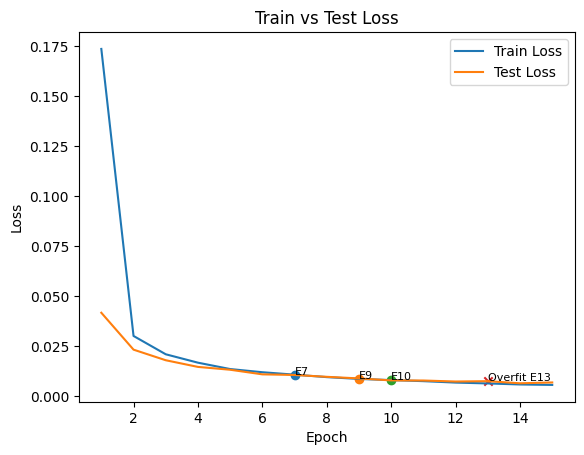

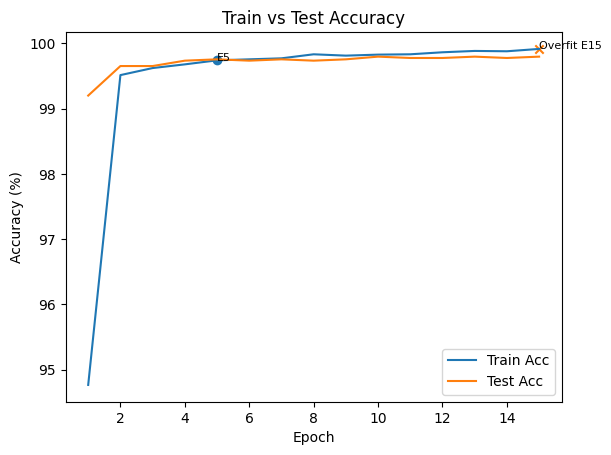

In [10]:
# 假设 train_loss, test_loss, train_acc, test_acc 已经在前面定义并填充完毕
epochs = np.arange(1, len(train_loss) + 1)

# 1. 绘制 Loss 曲线并标出“交叉点”和“过拟合点”
plt.figure()
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, test_loss, label='Test Loss')

# 找到“交叉点”（Train Loss 与 Test Loss 曲线相交的近似点）
diff_loss = np.array(train_loss) - np.array(test_loss)
# 计算符号变化的位置
ix_cross = np.where(np.sign(diff_loss[:-1]) != np.sign(diff_loss[1:]))[0]
for ix in ix_cross:
    # 画出相交点
    plt.scatter(epochs[ix], train_loss[ix], marker='o')
    plt.text(epochs[ix], train_loss[ix], f'E{ix+1}', fontsize=8)

# 找到“过拟合点”：train_loss 持续下降而 test_loss 开始上升的首个 epoch
overfit_epoch = None
for i in range(1, len(test_loss)):
    if test_loss[i] > test_loss[i-1] and train_loss[i] < train_loss[i-1]:
        overfit_epoch = i
        break
if overfit_epoch is not None:
    plt.scatter(epochs[overfit_epoch], test_loss[overfit_epoch], marker='x')
    plt.text(epochs[overfit_epoch], test_loss[overfit_epoch], f'Overfit E{overfit_epoch+1}', fontsize=8)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Train vs Test Loss')
plt.show()


# 2. 绘制 Accuracy 曲线并标出“交叉点”和“过拟合点”
plt.figure()
plt.plot(epochs, train_acc, label='Train Acc')
plt.plot(epochs, test_acc, label='Test Acc')

# “交叉点”
diff_acc = np.array(train_acc) - np.array(test_acc)
ix_cross_acc = np.where(np.sign(diff_acc[:-1]) != np.sign(diff_acc[1:]))[0]
for ix in ix_cross_acc:
    plt.scatter(epochs[ix], train_acc[ix], marker='o')
    plt.text(epochs[ix], train_acc[ix], f'E{ix+1}', fontsize=8)

# 同样用最大 gap 标记“过拟合点”
gap = np.array(train_acc) - np.array(test_acc)
of_epoch_acc = np.argmax(gap)
plt.scatter(epochs[of_epoch_acc], train_acc[of_epoch_acc], marker='x')
plt.text(epochs[of_epoch_acc], train_acc[of_epoch_acc], f'Overfit E{of_epoch_acc+1}', fontsize=8)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Train vs Test Accuracy')
plt.show()


## 测试推理效果
---

In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import tkinter as tk
from tkinter import filedialog

# 1. 定义设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 定义模型结构（要和训练时一致）
model = models.resnet50(pretrained=False)      # 这里 pretrained=False，因为我们要加载自己训练的权重
model.fc = nn.Linear(model.fc.in_features, 2) # 类别数要和训练时一致
model = model.to(device)

# 3. 加载权重
checkpoint = torch.load('best_resnet50.pth', map_location=device)
model.load_state_dict(checkpoint)

# 4. 切换到评估模式
model.eval()

# 5. 定义预处理（要和训练时保持一致）
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std =[0.229,0.224,0.225]),
])

# 6. 单张图片推理示例
def predict_image(img_path, model, transform, device):
    # 打开并预处理
    img = Image.open(img_path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)  # 增加 batch 维度
    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = probs.max(1)
    return pred.item(), conf.item()

# 用法示例
def select_image_file():
    root = tk.Tk()
    root.withdraw()  # 隐藏主窗口
    root.attributes('-topmost', 1)  # 设置窗口在所有窗口的最前面
    root.geometry("+0+0")  # 将窗口放置在屏幕的左上角
    file_path = filedialog.askopenfilename(
        title="选择要预测的图片",
        filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp"), ("All files", "*.*")]
    )
    return file_path

# 调用示例
img_path = select_image_file()
if img_path:
    pred_label, confidence = predict_image(img_path, model, transform, device)
    print(f'预测类别：{pred_label}，置信度：{confidence*100:.2f}%')
else:
    print("未选择任何文件。")


d:\miniconda3\envs\torch_cu124\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\miniconda3\envs\torch_cu124\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\28497\AppData\Local\Temp\ipykernel_19080\2453607424.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` w

预测类别：0，置信度：77.64%
